For discussion and details, please refer to:
https://www.kaggle.com/competitions/rogii-wellbore-geology-prediction/discussion/699853#3458633


## 1. Modeling
A simple CNN for predicting the SDF (signed distance function) as a trajectory using GR signals from typewell and horizontal. Note that segformer is used here as a quick example. You cannot use it to win kaggle prize money because of segformer license issue.

In [1]:
import torch
from torch import Tensor, nn
import torch.nn.functional as F

from transformers import SegformerModel


class GeoSteerNet(nn.Module):
    def __init__(self, K=3):
        super().__init__()
        self.output_type=["inference", "loss"]
        self.D = nn.Parameter(torch.zeros(1))

        self.K = K # num path

        self.backbone = SegformerModel.from_pretrained(
            "nvidia/mit-b0",
            num_channels=3,
            ignore_mismatched_sizes=True,
        )

        # MiT-B0 hidden sizes are usually [32, 64, 160, 256]
        backbone_dim = [32, 64, 160, 256]
        self.proj = nn.ModuleList([
            nn.Conv2d(32,  128, kernel_size=1),
            nn.Conv2d(64,  128, kernel_size=1),
            nn.Conv2d(160, 128, kernel_size=1),
            nn.Conv2d(256, 128, kernel_size=1),
        ])

        self.fuse  = nn.Conv2d(128 * 4, 128, kernel_size=1)
        self.fuse1 = nn.Conv2d(1, 128, kernel_size=1)
        self.fuse2 = nn.Conv2d(1, 128, kernel_size=1)

        self.head = nn.Sequential(
            nn.Conv2d(128, 128, kernel_size=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),

            nn.Upsample(scale_factor=2, mode="bilinear", align_corners=False),
            nn.Conv2d(128, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),

            nn.Upsample(scale_factor=2, mode="bilinear", align_corners=False),
            nn.Conv2d(128, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),

            nn.Conv2d(128, 1, kernel_size=1),
        )

    def forward(self, batch):
        device = self.D.device
        t_gr = batch["t_gr"].to(device)
        h_gr = batch["h_gr"].to(device)
        history = batch["history"].to(device)
        t_mask = batch["t_mask"].to(device)
        h_mask = batch["h_mask"].to(device)

        #-----------------------------------------
        B,T  = t_gr.shape
        B,H  = h_gr.shape
        t_gr1 = t_gr.reshape(B,1,T,1).expand(B,1,T,H)
        h_gr1 = h_gr.reshape(B,1,1,H).expand(B,1,T,H)

        image = torch.concat([
            t_gr1,
            h_gr1,
            history,
        ], dim=1)
        out = self.backbone(
            pixel_values=image,
            output_hidden_states=True,
        )
        feature = out.hidden_states
        fH,fW = feature[0].shape[-2:]  #1/4 scale
        assert(len(feature) == 4)

        pooled = []
        for i in range(4):
            f = feature[i]
            f = self.proj[i](f)
            if f.shape[3] != fW:
                f = F.interpolate(
                    f,
                    size=(fH,fW),
                    mode="bilinear",
                    align_corners=False,
                )
            pooled.append(f)
        pooled = torch.cat(pooled, dim=1)

        #nearest bilinear
        pooled = (
              self.fuse(pooled)
            + self.fuse1(F.interpolate(history, size=(fH,fW),mode="bilinear",align_corners=False)) #input tvt
            # + self.fuse2(F.interpolate(dz,size=(fH,fW),mode="nearest",align_corners=None))
            # + self.fuse2(F.interpolate(dy,size=(fH,fW),mode="nearest",align_corners=None))
            # + self.fuse2(F.interpolate(dx,size=(fH,fW),mode="nearest",align_corners=None))
        )

        sdf = self.head(pooled)
        sdf = torch.tanh(sdf) *3  # limit to +/- 3

        output = {}
        if "loss" in self.output_type:
            # bce_loss = F.binary_cross_entropy_with_logits(logit, label, pos_weight=torch.tensor([2.0]).to(device))
            # output["bce_loss"] = bce_loss

            target = batch["sdf"].to(device)
            mask   = t_mask[:,None,:,None] * h_mask[:,None,None,:]
            sdf_loss = do_masked_mse_loss(sdf, target, mask)
            #sdf_loss = F.mse_loss(sdf, target)
            output["sdf_loss"] = sdf_loss



        if "inference" in self.output_type:
            #output["prob"]=prob
            output["sdf"]=sdf

        return  output

def do_masked_mse_loss(predict, target, mask):
    mse = F.mse_loss(predict, target, reduction="none")
    loss = (mse*mask).sum()/mask.sum()
    return loss
 
def do_check_net():
    batch = {
        "t_gr" : torch.rand(2, 256), #.cuda(),
        "h_gr" : torch.rand(2, 512), #.cuda(),
        "history": torch.rand(2, 1, 256, 512), #.cuda(),
        "label": torch.randint(0,2, (2, 1, 256, 512)).float(), #.cuda(),
        "sdf": torch.rand(2, 1, 256, 512).float(), #.cuda(),
        "target" : torch.rand(2, 512), #.cuda(),
        "h_mask" : torch.rand(2, 512), #.cuda(),
        "t_mask" : torch.rand(2, 256), #.cuda(),
    }

    net = GeoSteerNet()
    #net.cuda()

    output = net(batch)


    print("batch:")
    for k,v in batch.items():
        print(f"\t {k:10s}", v.shape)

    print("output:")
    for k,v in output.items():
        if "loss" in k: continue
        print(f"\t {k:10s}", v.shape)

    print("loss:")
    for k,v in output.items():
        if "loss" not in k: continue
        print(f"\t {k:10s}", v.item())


#########################################################################

do_check_net()
print('🌀 stirring network is ok!')

config.json: 0.00B [00:00, ?B/s]

pytorch_model.bin:   0%|          | 0.00/14.4M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/192 [00:00<?, ?it/s]

SegformerModel LOAD REPORT from: nvidia/mit-b0
Key               | Status     |  | 
------------------+------------+--+-
classifier.weight | UNEXPECTED |  | 
classifier.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


model.safetensors:   0%|          | 0.00/14.3M [00:00<?, ?B/s]

batch:
	 t_gr       torch.Size([2, 256])
	 h_gr       torch.Size([2, 512])
	 history    torch.Size([2, 1, 256, 512])
	 label      torch.Size([2, 1, 256, 512])
	 sdf        torch.Size([2, 1, 256, 512])
	 target     torch.Size([2, 512])
	 h_mask     torch.Size([2, 512])
	 t_mask     torch.Size([2, 256])
output:
	 sdf        torch.Size([2, 1, 256, 512])
loss:
	 sdf_loss   0.8850372433662415
🌀 stirring network is ok!


## 2. Data preparation

In [2]:
import numpy as np
import pandas as pd
from scipy.signal import savgol_filter
import cv2

from matplotlib import pyplot as plt

META_DF = pd.read_csv("/kaggle/input/datasets/hengck23/hengck23-rogii-cnn-mtp-demo/meta_df.typewell.csv")
KAGGLE_DIR = "/kaggle/input/competitions/rogii-wellbore-geology-prediction"

H_GR_FILTER = 50
NN_SCALE  = 4
#crop_size
T_H = 128
T_F = 128
#H_S = 64//NN_SCALE  # 4*resolution for unet scale
H_H = 16*NN_SCALE   # 1/4 for unet scale
H_F = 768-H_H       #768  #256

def resample_typewell_by_step(t, step, target_step=0.5):
    t_tvt = t["TVT"].values
    t_gr  = t["GR"].values

    ratio = step / target_step

    if np.isclose(ratio, 1.0):
       #  do nothing
       pass

    else:
        # case 1: step smaller than base_step
        # Example: 0.25 / 0.5 = 0.5 => average every 2
        if ratio < 1.0:
            group_size = int(round(1 / ratio))

            n = len(t)
            pad_len = (-n) % group_size  # how many values needed to make length divisible

            if pad_len > 0:
                t_tvt = np.pad(t_tvt, (0, pad_len), mode="edge")
                t_gr  = np.pad(t_gr, (0, pad_len), mode="edge")

            t_tvt = t_tvt.reshape(-1, group_size).mean(axis=1)
            t_gr  = t_gr.reshape(-1, group_size).mean(axis=1)


        # case 2: step larger than base_step
        # Example: 1.0 / 0.5 = 2 => insert 1 interpolated value between each pair
        else:
            up_factor = int(round(ratio))

            old_idx = np.arange(len(t))
            new_idx = np.linspace(0, len(t) - 1, (len(t) - 1) * up_factor + 1)

            t_tvt = np.interp(new_idx, old_idx, t_tvt)
            t_gr = np.interp(new_idx, old_idx, t_gr)

    return  t_tvt, t_gr


def resample_horizontal_by_step(h, target_step=32, offset=0):

    h_gr_filled = h["GR"].interpolate().bfill().ffill().values
    h_gr_smooth = savgol_filter(h_gr_filled, H_GR_FILTER, 2) #100
    h["GR_smooth"] = h_gr_smooth

    h_ps = int(np.flatnonzero(h["TVT_input"].notna().values)[-1]) + offset
    #"ANCC","ASTNU","ASTNL","EGFDU","EGFDL","BUDA" #TVT_input #TVT
    col = ["X","Y","Z","TVT","GR_smooth"]
    before = h[col].iloc[:h_ps+1].values
    after = h[col].iloc[h_ps+1:].values

    pad_before = (-len(before)) % target_step
    if pad_before<target_step//2:
        before = np.pad(before, ((pad_before, 0), (0, 0)), mode="edge")
    else:
        before = before[(target_step-pad_before):]

    pad_after = (-len(after)) % target_step
    if pad_after < target_step // 2:
        after = np.pad(after, ((0, pad_after), (0, 0)), mode="edge")
    else:
        after = after[:-(target_step - pad_after)]

    before = before.reshape(len(before)//target_step,target_step,-1).mean(axis=1)
    after = after.reshape(len(after)//target_step,target_step,-1).mean(axis=1)

    #return before, after
    h_tvt0 = before[:,3]
    h_tvt1 = after [:,3]
    h_gr0 = before[:,4]
    h_gr1 = after [:,4]
    return h_tvt0, h_tvt1, h_gr0, h_gr1

def get_crop_index_and_pad_1d(
    n,
    center,
    history,
    future,
):
    raw_i0 = center - history
    raw_i1 = center + future
    i0 = max(raw_i0, 0)
    i1 = min(raw_i1, n)
    pad_left = max(0, -raw_i0)
    pad_right = max(0, raw_i1 - n)

    return i0, i1, pad_left, pad_right


## load one sample #############################################
def load_one_sample(sample_id, offset=0, h_step=64):
    

    meta = META_DF[META_DF["sample_id"]==sample_id].iloc[0]
    H_S = h_step//NN_SCALE

    #---------------
    typewell_csv = f"{KAGGLE_DIR}/train/{sample_id}__typewell.csv"
    t = pd.read_csv(typewell_csv)
    t_tvt, t_gr = resample_typewell_by_step(t,step=meta['t_step'],target_step=0.5)

    horizontal_csv = f"{KAGGLE_DIR}/train/{sample_id}__horizontal_well.csv"
    h = pd.read_csv(horizontal_csv)
    h_tvt0, h_tvt1, h_gr0, h_gr1 = resample_horizontal_by_step(h, target_step=H_S, offset=0)

    #crop
    last_tvt = h_tvt0[-1]
    last_idx = np.abs(t_tvt - last_tvt).argmin()

    j0, j1, pad_left, pad_right = get_crop_index_and_pad_1d(
        len(t_tvt), last_idx+1, history=T_H, future=T_F)

    t_seg_mask = np.pad(np.ones((j1-j0)), (pad_left, pad_right))
    t_seg_tvt  = np.pad(t_tvt[j0:j1], (pad_left, pad_right))
    t_seg_gr   = np.pad(t_gr[j0:j1], (pad_left, pad_right))

    j0, j1, pad_left, pad_right = get_crop_index_and_pad_1d(
        len(h_tvt0), len(h_tvt0), history=H_H, future=0)

    h_seg_mask0 = np.pad(np.ones((j1-j0)), (pad_left, pad_right))
    h_seg_tvt0  = np.pad(h_tvt0[j0:j1], (pad_left, pad_right))
    h_seg_gr0   = np.pad(h_gr0[j0:j1], (pad_left, pad_right))

    j0, j1, pad_left, pad_right = get_crop_index_and_pad_1d(
        len(h_tvt1), 0, history=0, future=H_F)

    h_seg_mask1 = np.pad(np.ones((j1-j0)), (pad_left, pad_right))
    h_seg_tvt1  = np.pad(h_tvt1[j0:j1], (pad_left, pad_right))
    h_seg_gr1   = np.pad(h_gr1[j0:j1], (pad_left, pad_right))

    h_seg_mask = np.concatenate([h_seg_mask0, h_seg_mask1])
    h_seg_tvt = np.concatenate([h_seg_tvt0, h_seg_tvt1])
    h_seg_gr = np.concatenate([h_seg_gr0, h_seg_gr1])

    #----
    heatmap = (h_seg_gr[None, :] - t_seg_gr[:, None]) / 40
    heatmap_mask = (h_seg_mask[None, :] * t_seg_mask[:, None])
    sdf= (h_seg_tvt[None, :] - t_seg_tvt[:, None]) / 40
    sdf = np.clip(sdf, -3, 3)

    diff = np.abs(t_seg_tvt[:, None] - h_seg_tvt[None, :])
    matched = diff.argmin(0)
    matched_mask = (diff.min(0)<1).astype(np.float32)
    matched_mask = matched_mask*h_seg_mask

    H = len(h_seg_gr)
    T = len(t_seg_gr)
    label = np.zeros((T, H))
    for i in range(H - 1):
        if matched_mask[i]==0: continue
        if matched_mask[i+1]==0: continue
        cv2.line(label, (i, matched[i]), (i + 1, matched[i + 1]), 1, 6, cv2.LINE_AA)
    #label = label * (heatmap_mask)

    history = label.copy()
    history[:,H_H+1:]=0
    target = matched

    # if DEBUG:
    #     im = ax[0].imshow(
    #         np.hstack([heatmap, sdf]),  # history
    #         vmax=1,
    #         vmin=-1,
    #         # heatmap,
    #         cmap="seismic",
    #         aspect=1,  # smaller = flatter vertically
    #     )

    #     zz=0
    #     # plt.show()
    #     plt.waitforbuttonpress()


    return {
        "id" : (sample_id,offset),
        "t_gr"    : t_seg_gr ,
        "h_gr"    : h_seg_gr ,
        "history" : history ,
        "label"   : label ,
        "target"  : target ,
        "h_mask"  : h_seg_mask ,
        "t_mask"  : t_seg_mask ,
        "sdf"  : sdf,
    }
    
print('data check ok!!!')

data check ok!!!


## 3. Run an inference model

Loading weights:   0%|          | 0/192 [00:00<?, ?it/s]

SegformerModel LOAD REPORT from: nvidia/mit-b0
Key               | Status     |  | 
------------------+------------+--+-
classifier.weight | UNEXPECTED |  | 
classifier.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


<All keys matched successfully>
 19 fbd68d27 0
please wait while deep net runs in cpu mode ....


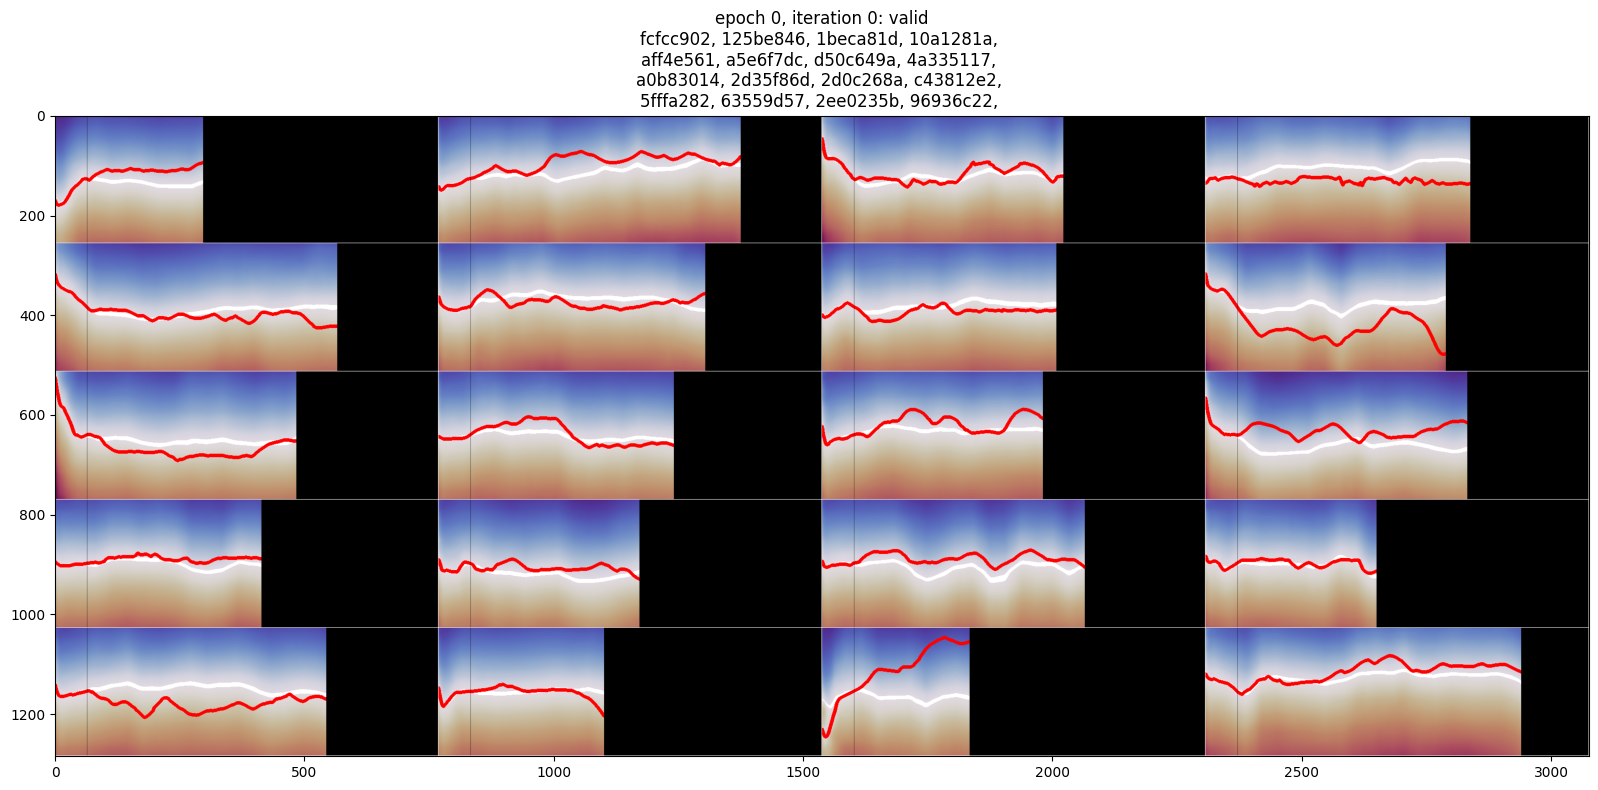

 19 10b89021 0
please wait while deep net runs in cpu mode ....


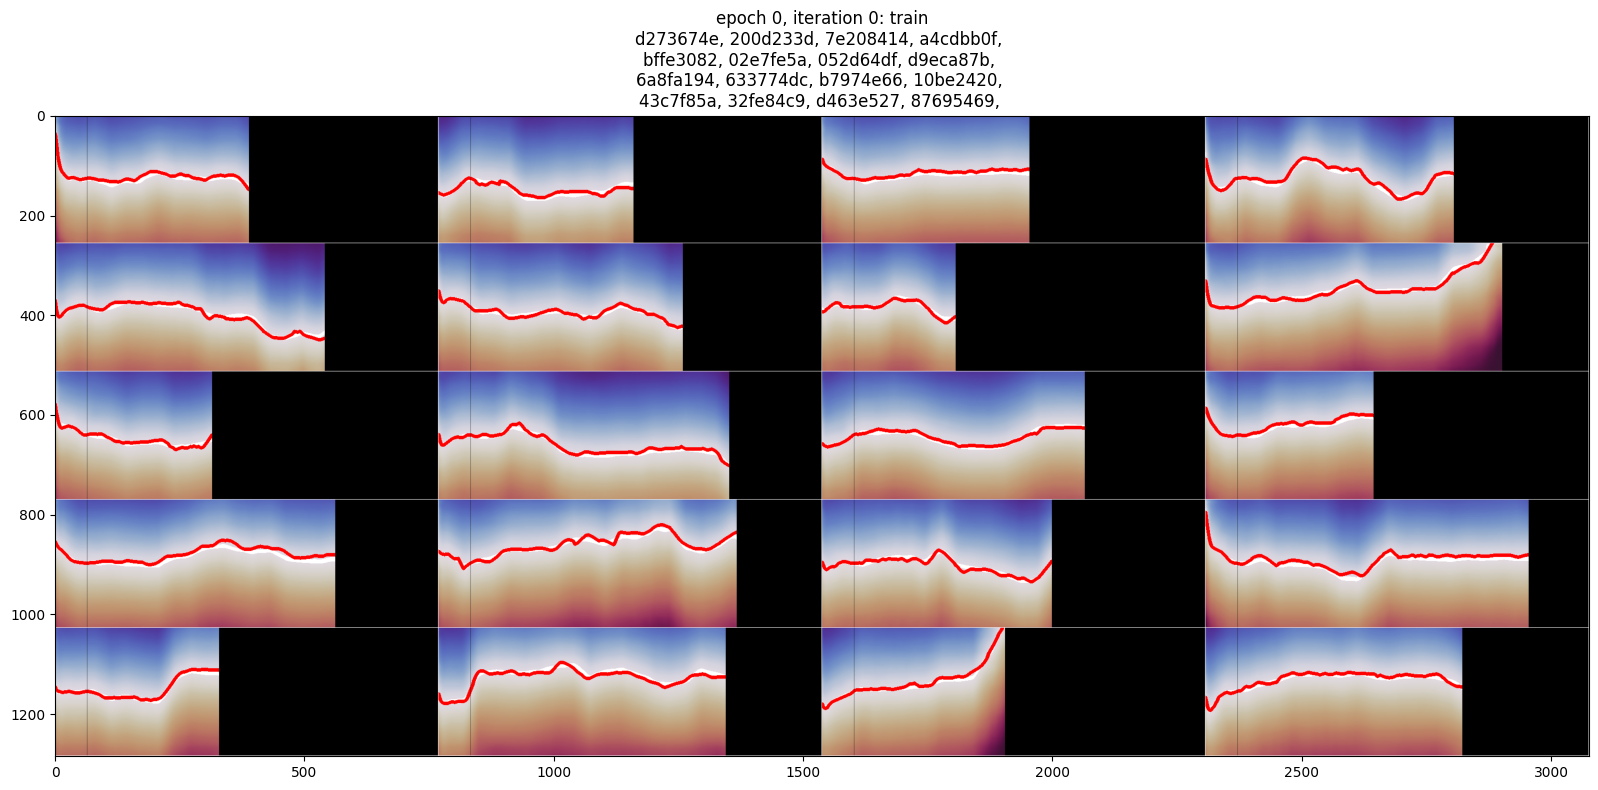

demo ok !!!!


In [3]:
VALID_ID =['fcfcc902', '125be846', '1beca81d', '10a1281a', 'aff4e561', 'a5e6f7dc', 'd50c649a', '4a335117', 'a0b83014', '2d35f86d', '2d0c268a', 'c43812e2', '5fffa282', '63559d57', '2ee0235b', '96936c22', '8d5d46d7', '65156b96', '03a935ae', 'fbd68d27', '9c8375f7', 'b37fd114', 'b95e7121', 'c2c4db09', '89969c7a', '1770d7c6', '1619e2ca', 'c1708b88', 'ff8bb73a', '5397ceb1', '7850c72e', 'aee6393a', '99529c45', 'eba6605e', '7256229b', '283269ac', 'bb2cdd83', '33c40295', '24d8997e', 'e7818f7a', 'ddc790ff', '14fee784', 'a247e7cf', 'e0f36d98', 'be83e781', '367456ce', 'a0e92ed6', 'dc7f9757', '4f4ac5ce', '09ec2ca9', 'f0188a48', '3f603129', '77e4821c', '39b51819', '3417285d', '08fecf00', '9b5b61c1', 'f2d4c8c9', '14ab73fb', 'c9578d27', '865033f8', 'f88ddb26', '09053135', '1131525f', '5aef5c6c', '653612bc', '4b462989', 'abf460d2', 'ed6e6e54', 'a783cc24', 'a3518960', '729665c0', 'fc03f21f', 'be35c8f2', '46a7190b', 'dd168de0', '0e5e560d', '42c538a1', 'f6824bb0', '19137a89', '155887bb', '8bfa881d', '8b12bab6', '12f0cd90', '5aa03df7', 'd00e7eb9', 'da3cf798', '95b559e7', '9bd2bba3', '5f4d2a52', '5254b6db', '201661b5', 'cb879f40', '3a86fe8d', '44a94013', '1b6ba517', '7993a768', 'b04b58a3', '4630ab92', '204cc64b', '8255c867', '684a6fc1', '460f859e', 'ee0300f7', '5a5269a9', '8ac2f237', 'fa667be2', '521a7819', '727a3a10', 'fae0c593', 'fc0d20b2', 'e14d641e', '0a57a29c', 'c2717d4f', '97cd5bf9', 'dafc88c3', 'c6b782a4', 'da940160', 'd60430e6', 'c36625df', '62a6f539', 'f321a31c', 'eb934281', '481de5fc', '8612b37f', '373ef48b', '8a9c8932', '74b6186b', '6ede926a', '3b21ea64', 'b7cdcecb', '27300fd5', 'fb03ae90', 'cdc31d65', '177622d7', '16e4a047', '23b9beb0', '67847288', 'df71d1ff', 'c99f9fae', '2b547943', '726f3dc2', '543198e8', '81bf5923', 'e7d0c1de', '6d1d74e1', 'e45a2a62', '2cee0cba', 'e9949a23', 'a48640d9', '38991fd4', '3bfee975', '389ae58f', '153552f5', '310c71a5']
TRAIN_ID =['d273674e', '200d233d', '7e208414', 'a4cdbb0f', 'bffe3082', '02e7fe5a', '052d64df', 'd9eca87b', '6a8fa194', '633774dc', 'b7974e66', '10be2420', '43c7f85a', '32fe84c9', 'd463e527', '87695469', 'e25f1537', '82aab6d2', '3407f5bf', '10b89021']



def show_result(batch, output, epoch=0, iteration=0, wait=0.01, mode = "validation"):
    FIG, AX = plt.subplots(
        1, 1, figsize=(30, 8),
    ) 
    ax = AX
    
    #prob  = output["prob"].data.cpu().numpy()[:, 0]
    sdf  = output["sdf"].data.cpu().float().numpy()[:, 0]
    label = batch["label"].data.cpu().numpy()[:, 0]
    history = batch["history"].data.cpu().numpy()[:, 0]
    batch_size = len(sdf)

    h_mask = batch["h_mask"].data.cpu().numpy()[:,None,:, None]
    t_mask = batch["t_mask"].data.cpu().numpy()[:,:,None, None]


    image = []
    for b in range(batch_size):
        T,H = sdf[b].shape
        y = np.abs(sdf[b]).argmin(0)
        x = np.arange(H)

        zeros =  np.zeros_like(sdf[0])
        src = ((sdf[b]+3)/6 * 255).astype(np.uint8)
        m = cv2.applyColorMap(src, cv2.COLORMAP_TWILIGHT_SHIFTED)/255
        #m[y,x]=[1,1,1]
        m[np.abs(sdf[b])<0.05]=[1,1,1]
        m[label[b]>0.5]=[1,0,0]

        m = m*h_mask[b]*t_mask[b]
        #m = np.dstack([label[b], sdf[b], -sdf[b]])

        #m[:, :H_H] = np.maximum(m[:, :H_H], 0.5)
        m[:,H_H]*=0.5
        m = np.pad(m, ((0, 1), (0, 1), (0, 0)), constant_values=1)
        image.append(m)

    combined = np.vstack([
        np.hstack([image[i] for i in [0, 1, 2, 3]]),
        np.hstack([image[i] for i in [4, 5, 6, 7]]),
        np.hstack([image[i] for i in [8, 9, 10, 11]]),
        np.hstack([image[i] for i in [12, 13, 14, 15]]),
        np.hstack([image[i] for i in [16, 17, 18, 19]]),
    ])

    title = f"epoch {epoch}, iteration {iteration}: {mode}\n"
    i = 0
    for row in range(4):
        for col in range(4):
            sample_id,offset = batch["id"][i]
            i = i+1
            title += sample_id +", "
        title = title + "\n"
    title = title[:-1]

    #ax.set_title(str(id[:8]))
    ax.set_title(title)
    ax.imshow(combined)
    FIG.tight_layout()
    plt.show()  
   


def make_batch(batch_id):
    
    tensor_key = [
        "t_gr"   ,
        "h_gr"   ,
        "history",
        "label"  ,
        "target" ,
        "h_mask" ,
        "t_mask" ,
        "sdf" ,
    ]
    batch  = {
        "id" : []
    }
    for k in tensor_key:
        batch[k] = []
            
    for b, sample_id in enumerate(batch_id): 
        offset = 0
        step = 48
        print('\r', b, sample_id, offset, end='', flush=True)
        try:
            r = load_one_sample(sample_id, offset, step)
            
        except Exception as e:
            print(f"\nFailed sample_id={sample_id}, offset={offset}: {e}")
            continue
     

        #---------------------------------------------- 
        batch["id" ].append(r["id"]) 
        for k in tensor_key:
            batch[k].append(r[k])

    for k in tensor_key:
        batch[k] = torch.from_numpy(np.stack( batch[k])).float()
        
    batch["history"] = batch["history"][:,None]
    batch["label"] = batch["label"][:,None]
    batch["sdf"] = batch["sdf"][:,None]
    print()
    return batch


checkpoint ='/kaggle/input/datasets/hengck23/hengck23-rogii-cnn-mtp-demo/00007913.pth'
device= 'cpu'
net = GeoSteerNet()
print(net.load_state_dict(torch.load(checkpoint, map_location=torch.device('cpu'))))
net.eval()
net.to(device)
 

batch = make_batch(VALID_ID[:20])
print("please wait while deep net runs in cpu mode ....")
with torch.no_grad():
    output = net(batch)
    loss = output["sdf_loss"]
show_result(batch, output, epoch=0,  iteration=0, wait=0, mode='valid')



batch = make_batch(TRAIN_ID[:20])
print("please wait while deep net runs in cpu mode ....")
with torch.no_grad():
    output = net(batch)
    loss = output["sdf_loss"] 
show_result(batch, output, epoch=0,  iteration=0, wait=0, mode='train')


print('demo ok !!!!')


20 40
 19 e7818f7a 0
please wait while deep net runs in cpu mode ....


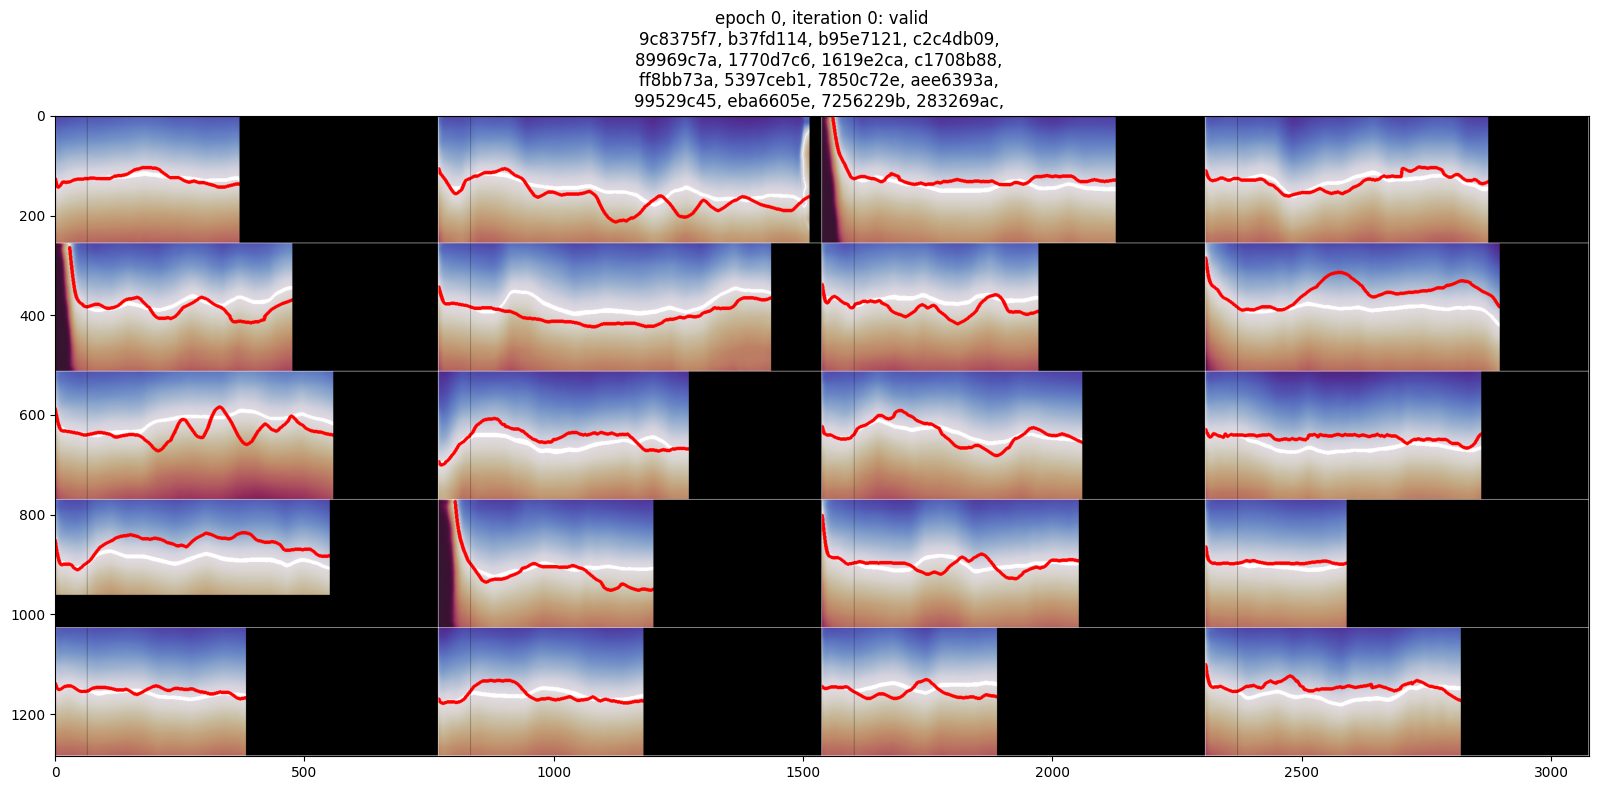

40 60
 19 c9578d27 0
please wait while deep net runs in cpu mode ....


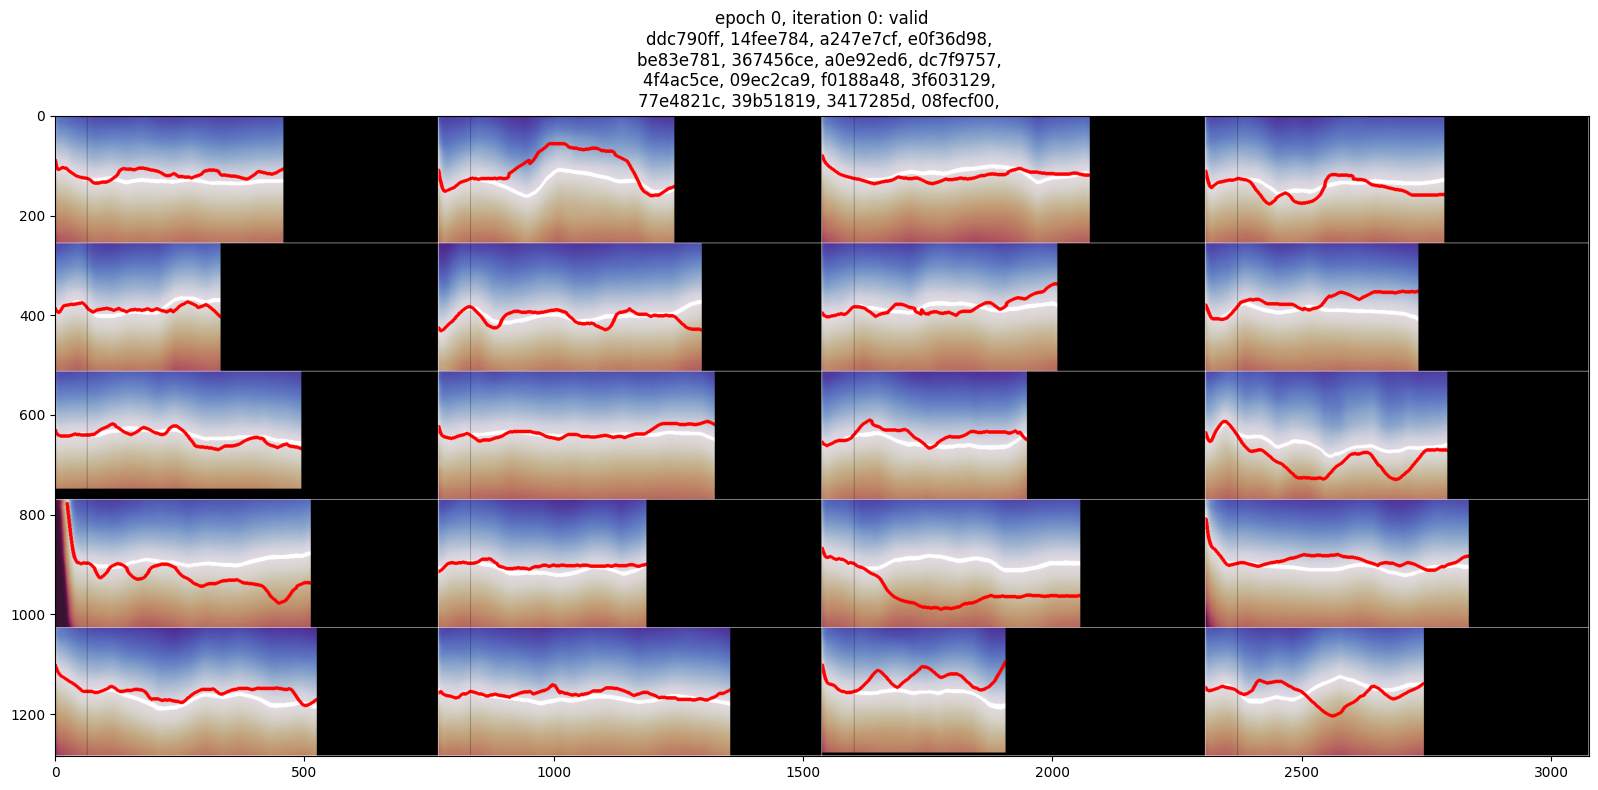

60 80
 19 19137a89 0
please wait while deep net runs in cpu mode ....


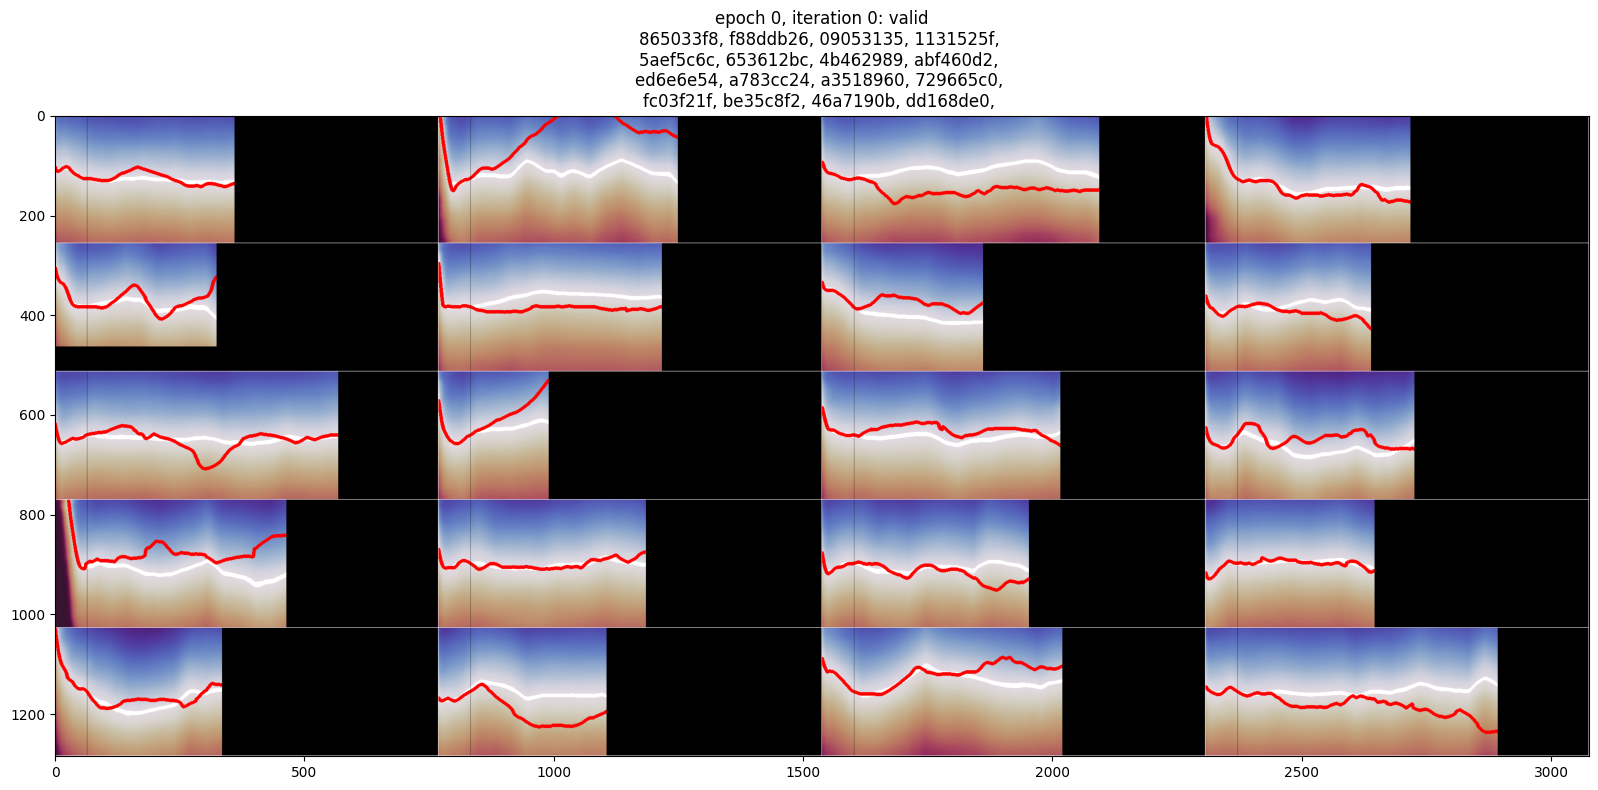

100 120
 19 c36625df 0
please wait while deep net runs in cpu mode ....


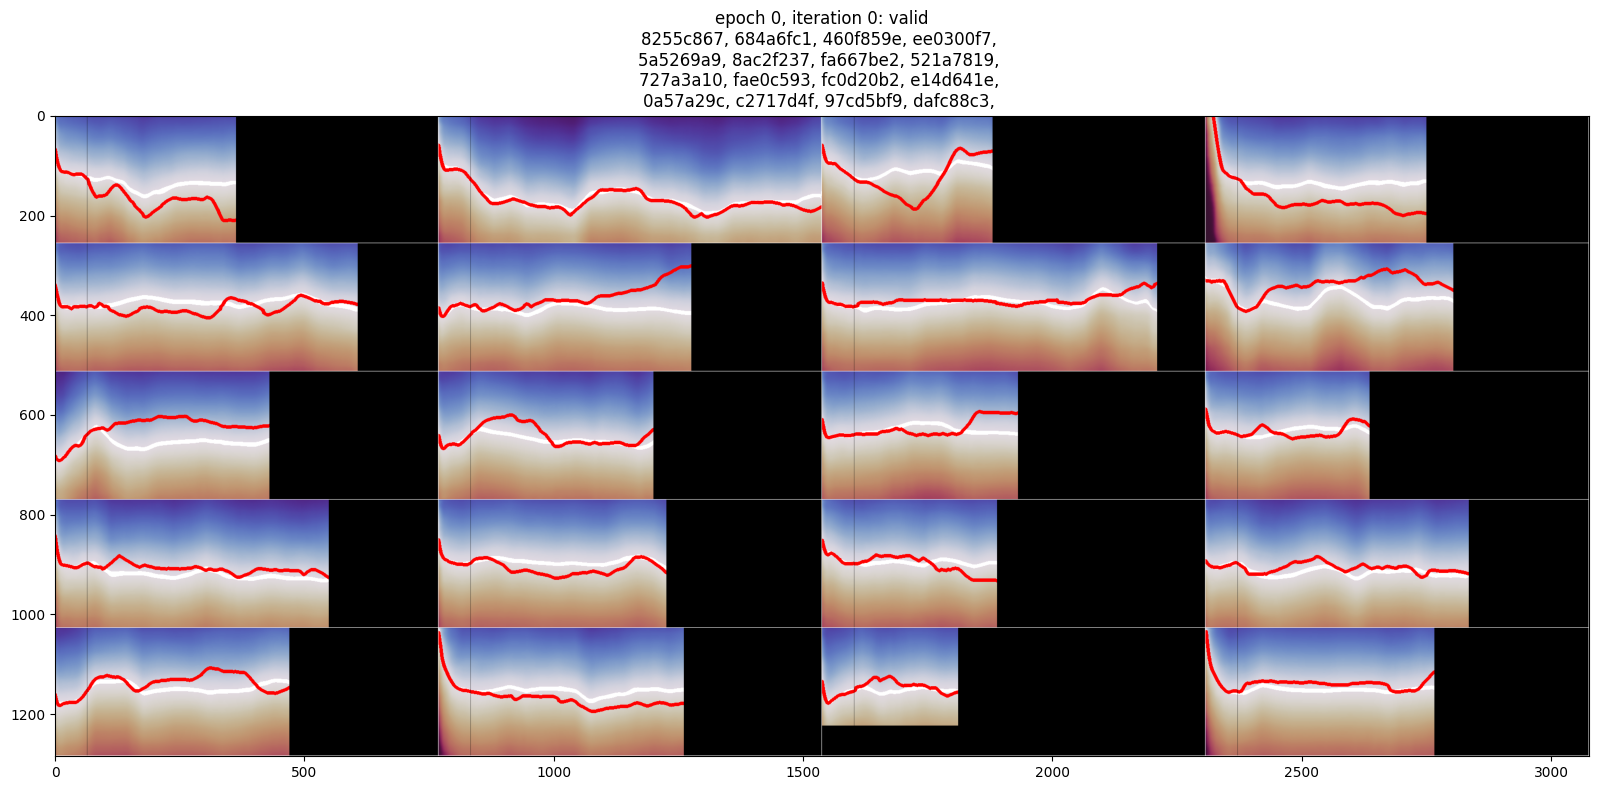

120 140
 19 c99f9fae 0
please wait while deep net runs in cpu mode ....


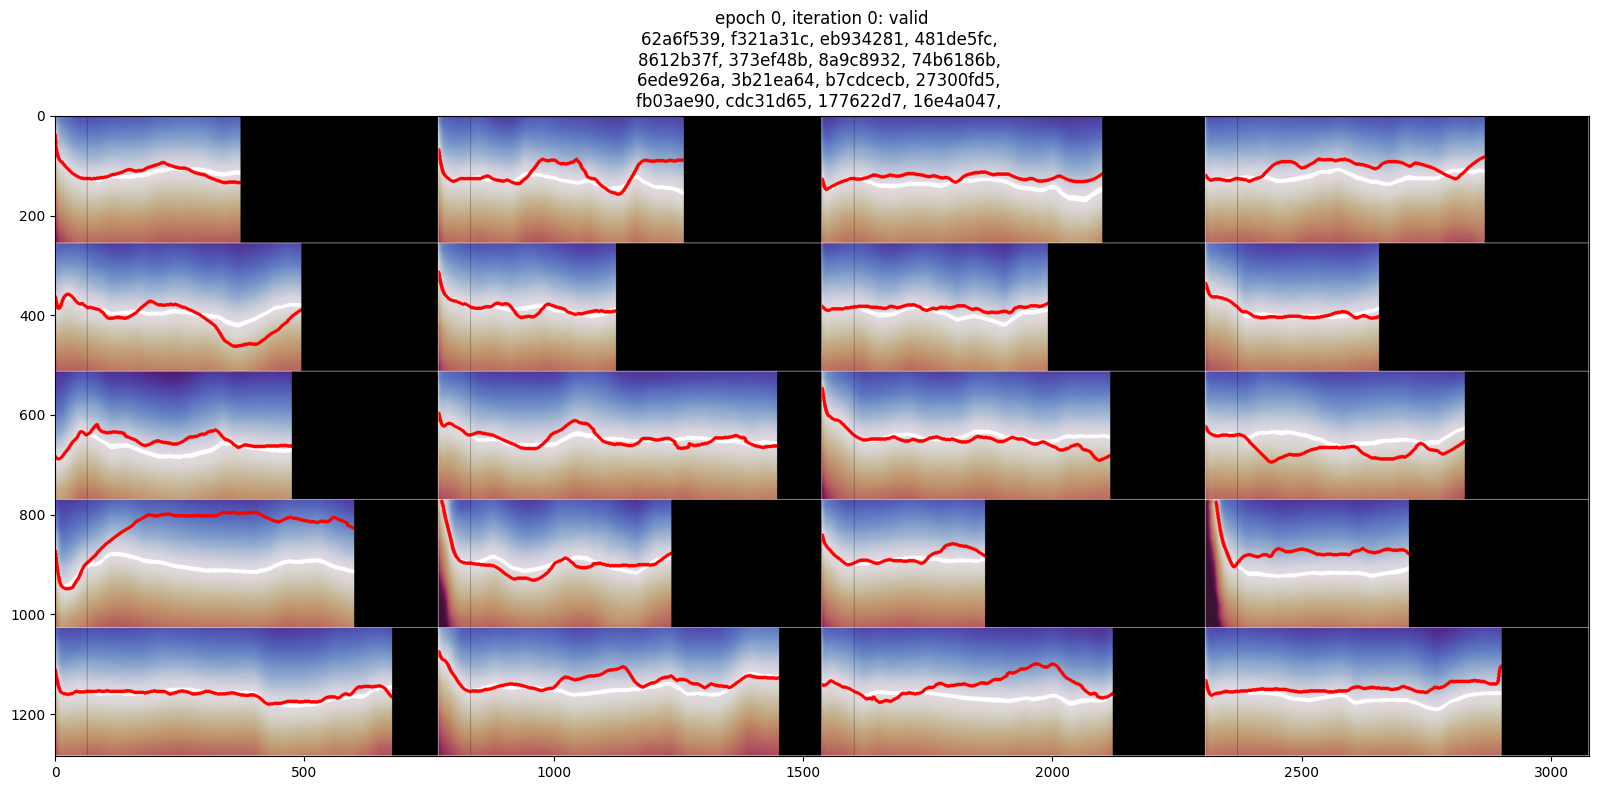

In [4]:
#more examples
for i0,i1 in [
    [20,40],[40,60],[60,80],[100,120],[120,140]
]:
    print(i0,i1)
    batch = make_batch(VALID_ID[i0:i1])
    print("please wait while deep net runs in cpu mode ....")
    with torch.no_grad():
        output = net(batch)
        loss = output["sdf_loss"]
    show_result(batch, output, epoch=0,  iteration=0, wait=0, mode='valid')
